In [127]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplot
from scipy.integrate import odeint

In [128]:
#define params

d1 = 1.35e-7 # min N-unit inverse

# Parameters for phagocytes
k1 = 4.9956e7 #N-unit Kg / min pg
k2 = 12.94907 # ND
h1 = 1693.9509 #pg/mL
h2 = 0.07212   # pg/mL
h3 = 147.68    # pg/mL
d2 = 0.1439   # 1/min

# Parameters for TGF beta
k3 = 1.546*1e-9 # mL/pg N-unit min
k4 = 0.5     # mL/pg min
h4 = 500#*1e6/100     # pg / mL
d3 = 0.031777 # 1/min

# Parameters for TNF alpha
h5 = 550e4   # N-unit
h6 = 0.1589  # pg/mL
k5 = 25.5194 # pg/mL min
k6 = 3.5514e4 # pg/mL min
h7 = 1.5495e3 # pg/mL
d4 = 0.0293 #0.0307/1   #mL/pg min

# Parameters for IL-10
b1 = 1187.2 # pg/mL min
k7 = 267480 #  pg/mL min
h8 = 8.0506e7 # N-unit
k8 = 43875 #  pg/mL min
h9 = 0.38  # pg/mL
d5 = 98.932 # 1/min
h10 = 791.27 #pg/mL

# Parameters for CRH
b2 = 0.001 # pg/mL min
k9 = 6.84e9 # pg/ml min
k10 = 1.7558e9#/(1e12))*(100^2) #(mL/pg^2)
k11 = 0.0667 # 1/min
d6 = 0.032 #1/min

# Parameters for ACTH
k12 = 2.3688e4 #1/min
k13 = 1.7778e5#/1e6)*100 #mL/pg
k14 = 112 #pg/mL min
h11 = 80 #pg/mL
d7  = 0.016 # 1/min

# Parameters for Cortisol
k15 = 4.2541e-04#*1e6/100 #pg mL / mL min pg
k16 = 12 # pg/mL
d8  = 0.0266 #1/min

# Parameters for the circadian rhythm
alpha = 300 #min
k     = 5 #ND
beta = 950 #min
L = 6 #ND
eps = 0.01 #ND
delta = 70#76.37 #min
T = 1440 # min
Nc = 1.9168


param = [d1,
k1,k2,h1,h2,h3,d2,
k3,k4,h4,d3,
h5,h6,k5,k6,h7,d4,
b1,k7,h8,k8,h9,d5,h10,
b2,k9,k10,k11,d6,
k12,k13,k14,h11,d7,
k15,k16,d8,
alpha, k, beta, L, eps, delta, T, Nc
 ]
param_log = np.log(param)

#Initial Conditions
endo_0 = 0
phag_0 = 0
TGFB_0 = 0.004/d3
TNF_0  = 0
IL10_0 = b1*h10/(d5*h10-b1)
CRH_0  = 2
ACTH_0 = 150
cort_0 = 1.9

IC = [ 2.0        ,  0.        ,  0.1595967 ,  0.        , 14.68266827,
       41.49891056, 39.97751646, 11.29827208]

In [129]:
## ODE Model ##

def ITIS(y,t,param):
 endo,phag,TGFB,TNF,IL10,CRH,ACTH,cort = y

 (d1,
k1,k2,h1,h2,h3,d2,
k3,k4,h4,d3,
h5,h6,k5,k6,h7,d4,
b1,k7,h8,k8,h9,d5,h10,
b2,k9,k10,k11,d6,
k12,k13,k14,h11,d7,
k15,k16,d8,
alpha, k, beta, L, eps, delta, T, Nc) = np.exp(param)

#Circadian Rhythm
 tm = (t * 60 - delta) % T
 R_1 = tm**k / (tm**k + alpha**k)
 R_2 = ((T - tm)**L) / ((T - tm)**L + beta**L)
 R_func = Nc*(R_1*R_2 + eps)

#Other things
 phag1 = 1 + k2 * (TNF / (h1 + TNF))
 phag2 = (h2 / (h2+TGFB)) * (h3 / (h3 + IL10))

 tnf1 = (phag / (h5 + phag)) * (h6**4 / (h6**4 + TGFB**4))
 tnf2 = k5 + k6 * (TNF / (h7 + TNF))

 il10_1 = k7 * (phag**3 / (h8**3 + phag**3)) + k8 * (TGFB**6 / (h9**6 + TGFB**6))

 crh1 = R_func * k9 * (CRH / (1+k10*cort**2)) ##[RESOLVE]

#Differential equations
 dendo = -d1 * endo * phag
 dphag = k1 * (phag1 * phag2) * endo - d2 * phag
 dTGFB = k3 * phag + k4 * cort / (h4 + cort) - d3 * TGFB
 dTNF = tnf1 * tnf2 - d4 * (TNF**2)
 dIL10 = b1 + il10_1 - d5 * (h10 / (h10 + IL10)) * IL10
 dCRH = b2 * 60 + crh1 * 60 + k11 * TNF - d6 * CRH * 60
 dACTH = k12 * (CRH / (1 + k13 * cort)) * 60 + k14 * (TNF**2 / (h11**2 + TNF**2)) - d7 * ACTH * 60
 dcort = k15 * (ACTH **2 / (1 + k16 * TGFB)) * 60 - d8 * cort * 60

 dy = [dendo,dphag,dTGFB,dTNF,dIL10,dCRH,dACTH,dcort]
 return dy

In [130]:
##Define upper and lower bounds
UB = np.array(np.log([theta + .2 * theta for theta in param]))
LB = np.array(np.log([theta - .2 * theta for theta in param]))

##Define time spaces
tstart = 0
t_end =24
dt = .05
tspace = np.arange(tstart,t_end,dt) ##not really being used
t_data = np.arange(0, t_end + dt, dt)


##Solve the model at nominal values
ode_options = {'rtol': 1e-6} ##[[ASK ABOUT THIS]]__
data_sol = odeint(ITIS, IC, t_data, args = (param_log,), **ode_options)


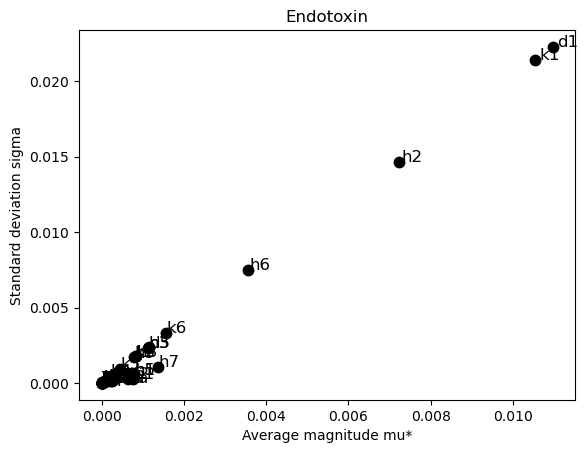

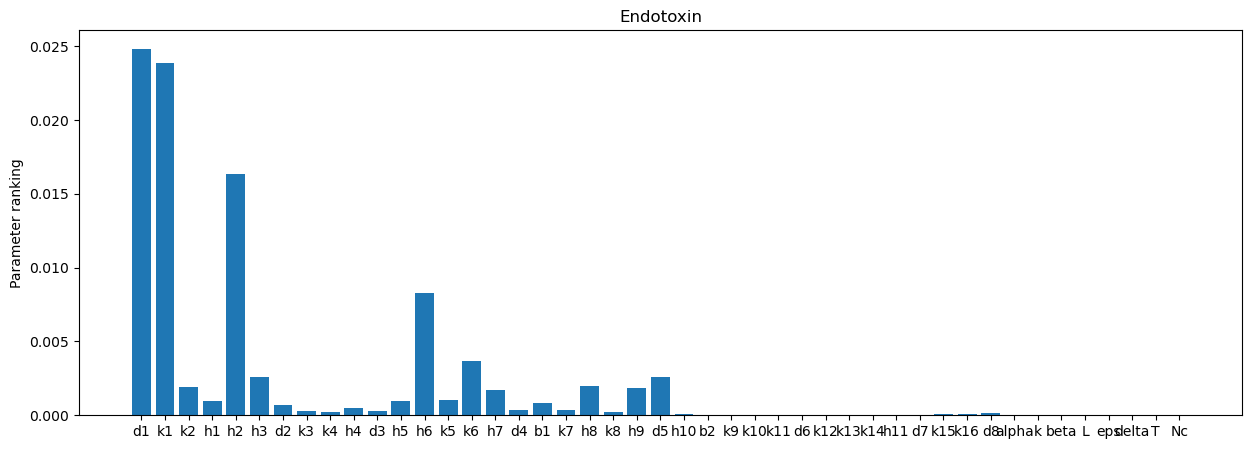

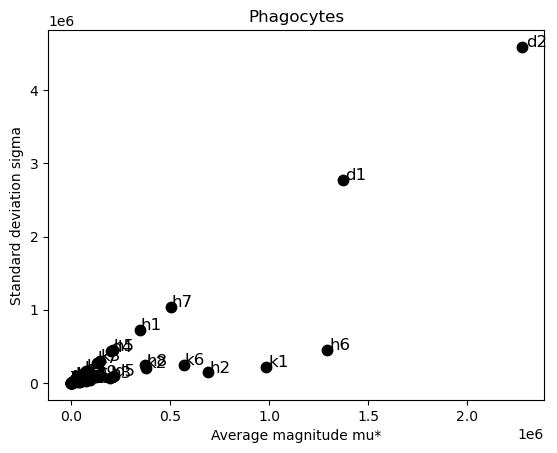

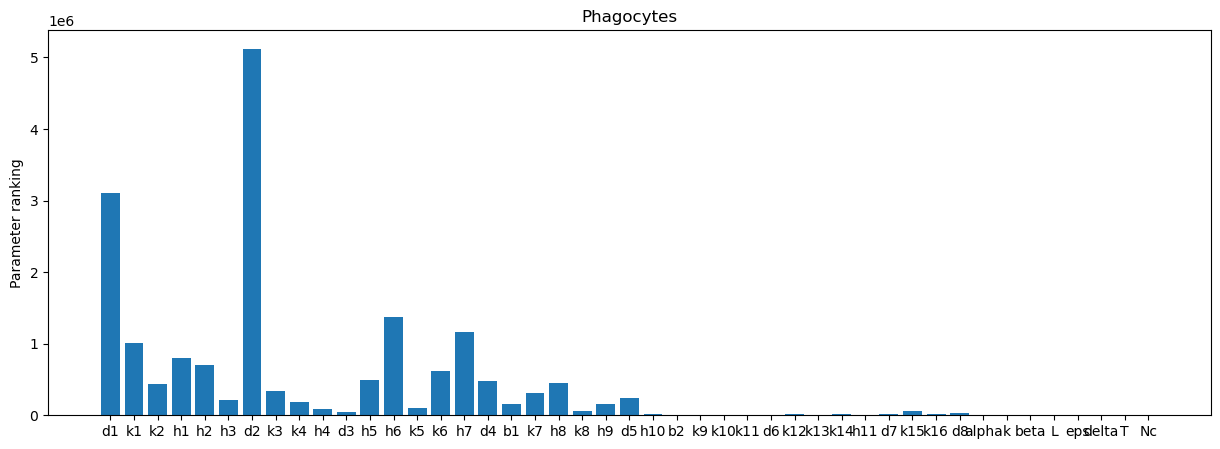

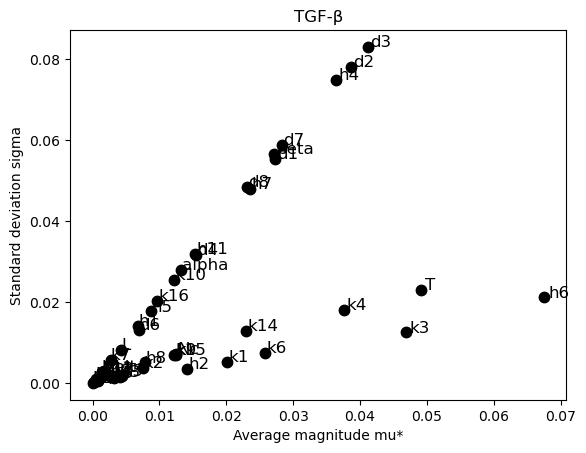

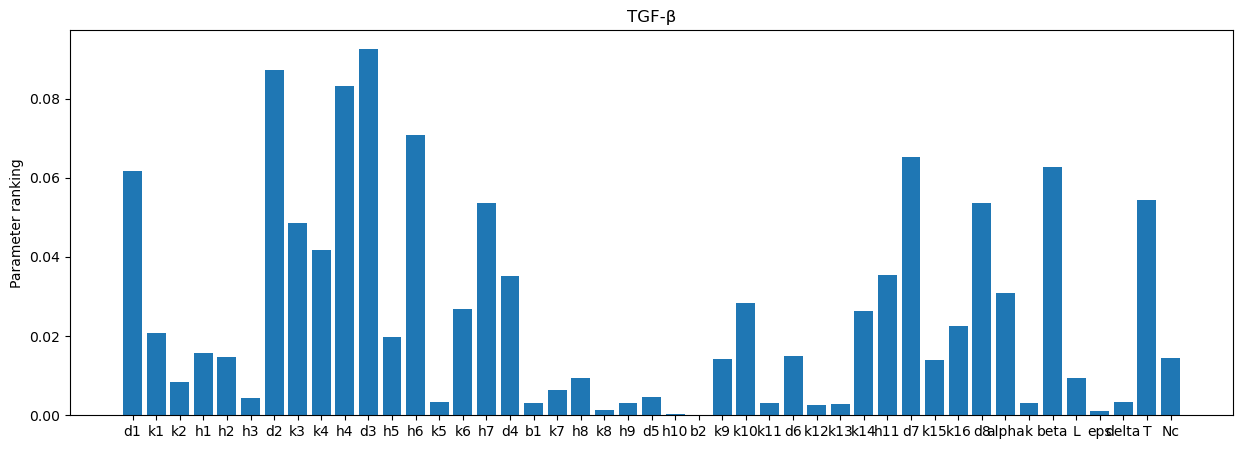

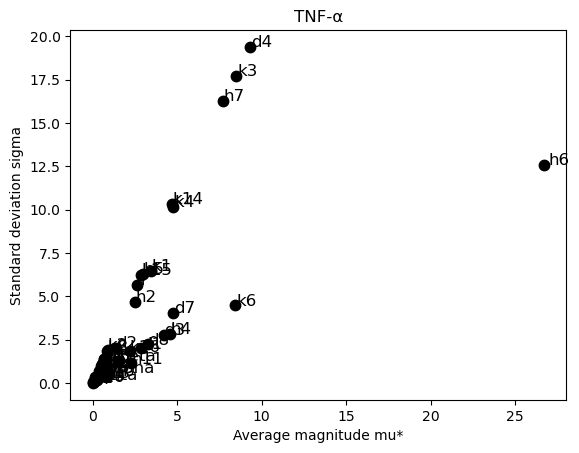

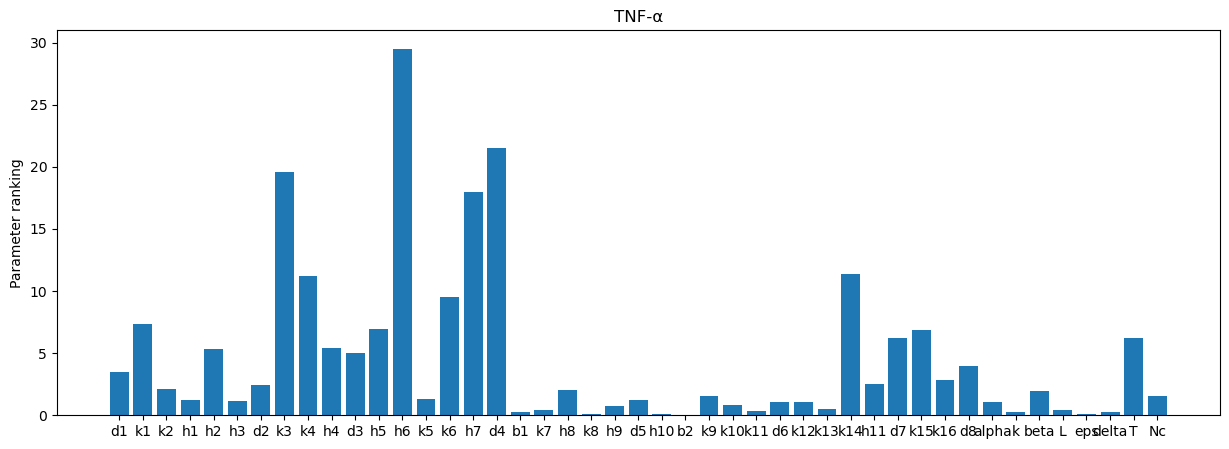

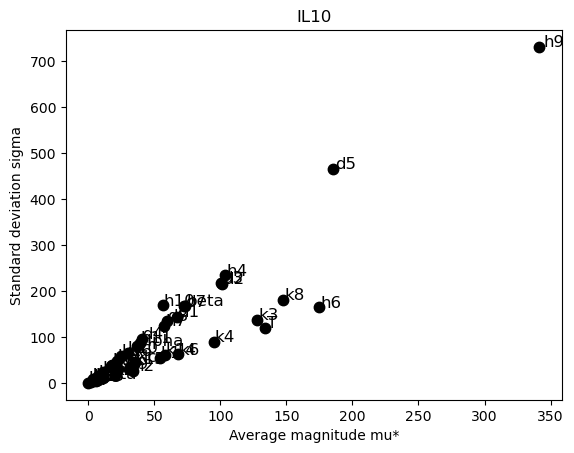

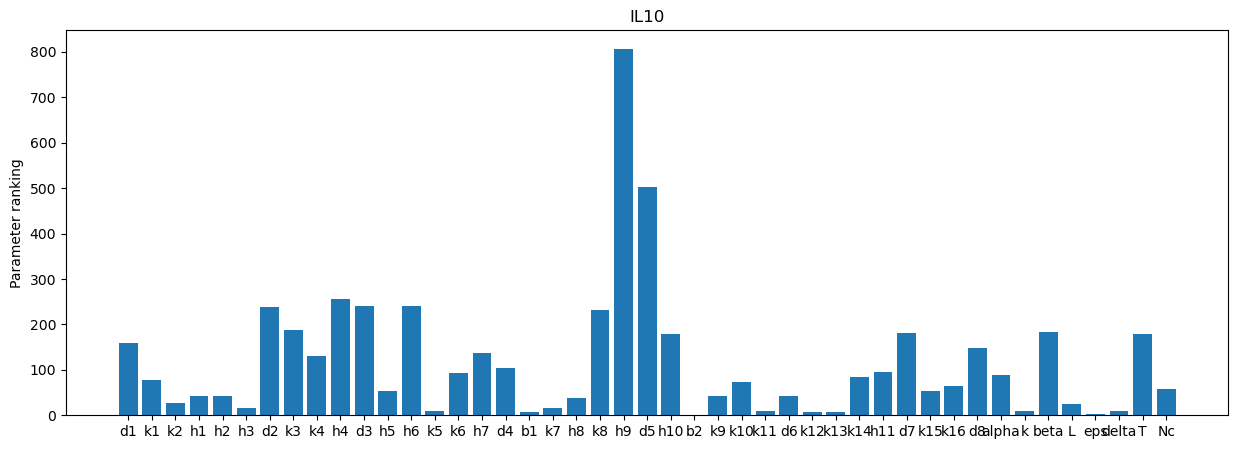

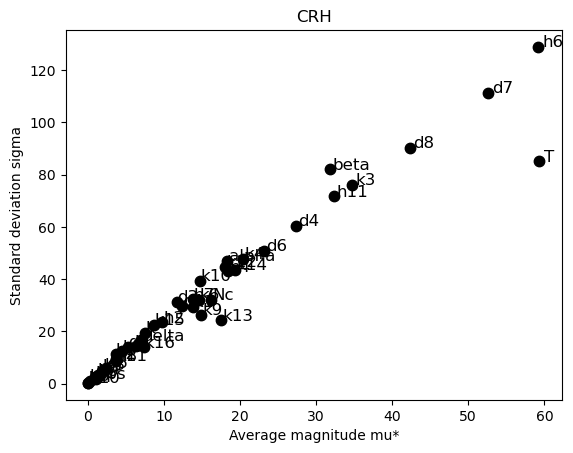

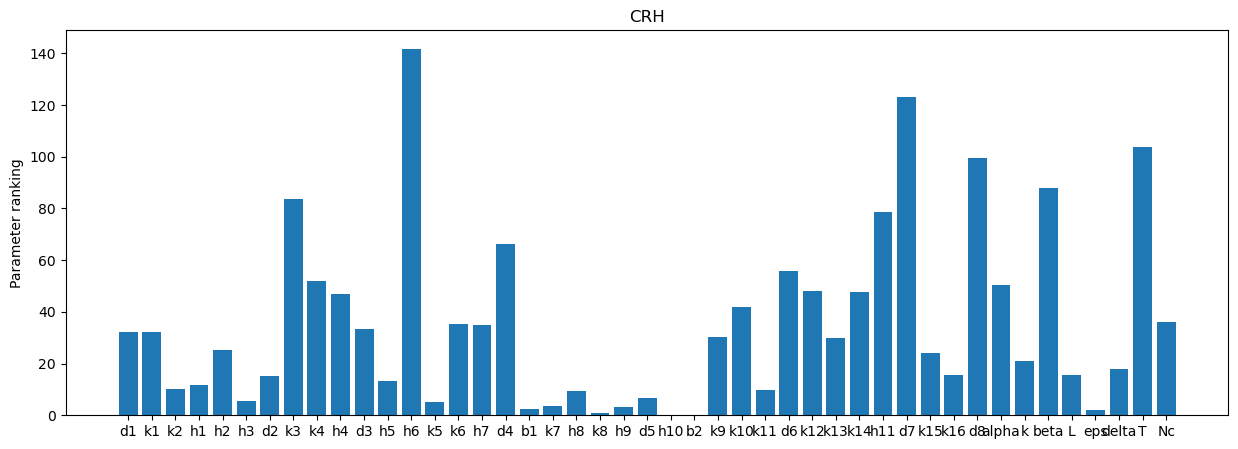

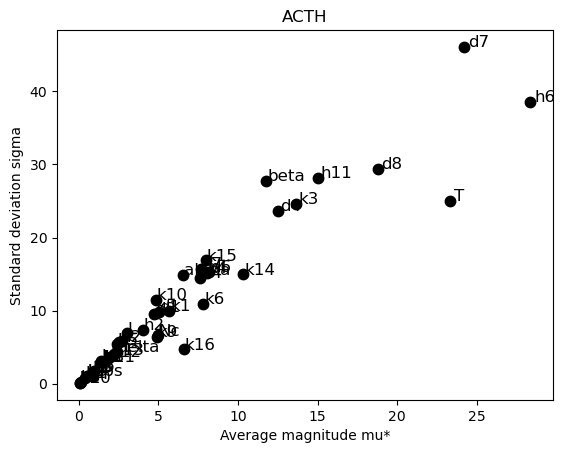

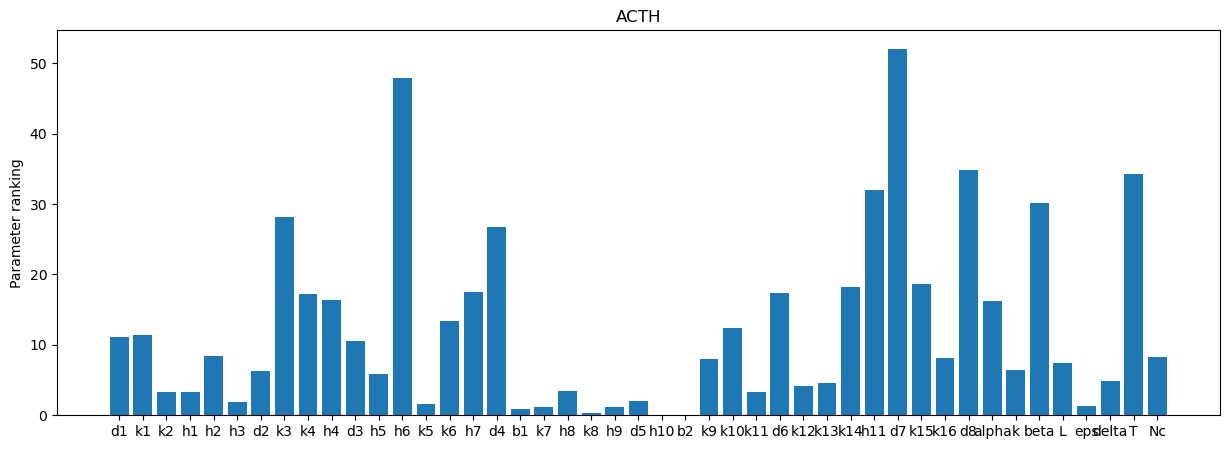

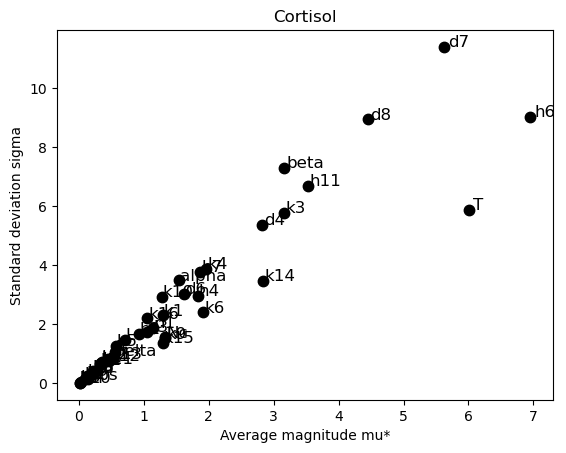

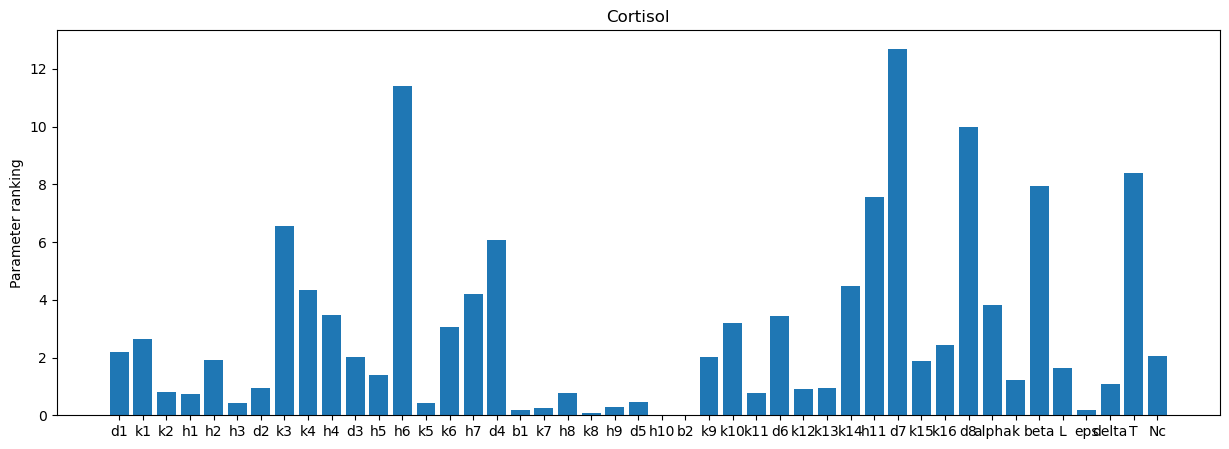

In [137]:
p = len(param)


paramtitles = ['d1',
'k1','k2','h1','h2','h3','d2',
'k3','k4','h4','d3',
'h5','h6','k5','k6','h7','d4',
'b1','k7','h8','k8','h9','d5','h10',
'b2','k9','k10','k11','d6',
'k12','k13','k14','h11','d7',
'k15','k16','d8',
'alpha', 'k', 'beta', 'L', 'eps', 'delta', 'T', 'Nc']

stateTitles = ['Endotoxin', 'Phagocytes', 'TGF-\u03b2','TNF-\u03B1','IL10','CRH','ACTH','Cortisol']
statTitles = ['\u03BC','\u03BC*', '\u03C3']

# mu_Norms = [(sum(mu[i]**2))**1/2 for i in range(p)]
# mu_starNorms = [(sum(mu_star[i]**2))**1/2 for i in range(p)]
# sigma_Norms = [(sum(sigma[i]**2))**1/2 for i in range(p)]

tpoints = len(mu[0][0])

#stat_Norms = [mu_Norms, mu_starNorms, sigma_Norms]
for k in range(len(states)):

    mu_Averages = [sum(mu[k][i])/tpoints for i in range(p)]
    mu_starAverages = [sum(mu_star[k][i])/tpoints for i in range(p)]
    sigma_Averages = [sum(sigma[k][i])/tpoints for i in range(p)]

    stat_Averages = [mu_Averages, mu_starAverages, sigma_Averages]

    mu_Sorted = np.sort(mu_Averages)
    mu_starSorted = np.sort(mu_starAverages)
    sigma_Sorted = np.sort(sigma_Averages)

    stat_Sorted = [mu_Sorted, mu_starSorted, sigma_Sorted]

    #Plot Morris for CRH + ACTH + cort over time for one param(DOES THIS EVEN MAKE SENSE?)
    # theta = 30
    # fig, ax = plt.subplots()
    # ax.plot(t_data, mu_star[k][theta], label='mu*')
    # # ax.plot(t_data, sigma[theta], label = 'sigma')
    # ax.set_title("Morris effects over time for " + paramtitles[theta])
    # plt.legend()
    # #plt.savefig('C:\\Users\\ayres\\Desktop\\RESEARCH, GRANTS, LIFE!!!!\\ITIS Analysis 25-26\\MorrisOverTimeh4.png')
    # plt.show()


    #Ranking procedure:

    # fig, (ax1, ax2, ax3) = plt.subplots(3,1, figsize = (5,15))
    # axs = [ax1, ax2, ax3]
    #
    # for j in range(3):
    #
    #     PoI = []
    #     for i in range(1,11):
    #         paramindex = stat_Averages[j].index(stat_Sorted[j][-i])
    #         PoI.append(paramtitles[paramindex])
    #
    #     axs[j].set_title(stateTitles[k] + " Parameters ranked by average " + statTitles[j])
    #     PoI.reverse()
    #     axs[j].bar(PoI, stat_Sorted[j][-10:])
    #
    # #plt.savefig('C:\\Users\\ayres\\Desktop\\RESEARCH, GRANTS, LIFE!!!!\\ITIS Analysis 25-26\\HPAMorrisTop10Ave.png')
    # plt.show()

    plt.figure()
    for i in range(p):
        plt.plot((mu_starAverages[i]), (sigma_Averages[i]), 'k.', markersize=15)
        plt.text((mu_starAverages[i]) * 1.01,(sigma_Averages[i]), paramtitles[i], fontsize=12)
    plt.title(stateTitles[k])
    plt.xlabel('Average magnitude mu*')
    plt.ylabel('Standard deviation sigma')

    plt.savefig('C:\\Users\\ayres\\Desktop\\RESEARCH, GRANTS, LIFE!!!!\\ITIS Analysis 25-26\\' + stateTitles[k] + 'ScatterRanking.png')
    plt.show()

    rank = np.sqrt(np.array(mu_starAverages)**2 + np.array(sigma_Averages)**2)
    plt.figure(figsize = (15,5))
    plt.title(stateTitles[k])
    plt.bar(range(len(rank)), rank)
    plt.xticks(range(len(rank)), paramtitles)
    plt.ylabel('Parameter ranking')

    plt.savefig('C:\\Users\\ayres\\Desktop\\RESEARCH, GRANTS, LIFE!!!!\\ITIS Analysis 25-26\\' + stateTitles[k] + 'BarRanking.png')
    plt.show()

In [131]:
# print(100*np.exp(LB)/np.exp(param_log))
# print(100*np.exp(UB)/np.exp(param_log))

In [132]:
##Define time spaces

# inj_event = 80 #Time injection occurs
#
# dt = .1
# t1 = np.arange(tstart,inj_event,dt)
# t2 = np.arange(inj_event, tend, dt)

In [133]:
##DETERMINES QOI for MORRIS
states = [0,1,2,3,4,5,6,7]

def get_model_output(params,IC,tspace):
    ode_options = {'rtol': 1e-6} ##[[ASK ABOUT THIS]]
    model_sol = odeint(ITIS, IC, tspace, args=(params,), **ode_options)
    # Here we define the quantity of interest
    # QoI = model_sol[-1,6] # Last Value ACTH
    # QoI = np.sum(model_sol[:,1]) #sum of infected
    #QoI = np.array([((model_sol[:,5]-data_sol[:,5])/data_sol[:,5])**2, ((model_sol[:,6]-data_sol[:,6])/data_sol[:,6])**2, ((model_sol[:,7]-data_sol[:,7])/data_sol[:,7])**2])
    QoI = []
    for i in states:
        QoI.append(model_sol[:,i])#least squares scaling

    return np.array(QoI)

In [134]:
##MORRIS FUNCTION
def Morris(get_model_output, UB, LB): ##BY MITCHEL COLEBANK
    # Number of samples, parameters, levels, and step size
    R = 100
    states = 8
    p = len(param)
    l = 60 ##Levels SHOULD BE EVEN
    delta = l / (2 * (l - 1)) ##Delta, by morris definition
    upper = UB
    lower = LB
    d = np.zeros((R, p, len(t_data),states))

    # Randomization algorithm
    A = np.zeros((p + 1, p))
    for i in range(p):
        A[i + 1:p + 1, i] = np.ones(p - i)

    #X = np.zeros(((p + 1) * R, p * R))
    F_storage = [[None for _ in range(R)] for _ in range(p + 1)]
    qstar = np.random.uniform(0, 1, (R, p)) #Fill Rxp matrix with random values between 0, 1. Book notes this might be bad for high dimensional problems
    Jp = np.ones((p + 1, p))
    J1 = np.ones((p + 1, 1))
    P = np.eye(p) #Identity matrix, 45x45. Book has it flipped so 1's are in bottom left and right?
    UL_MAT = np.eye(p) * (upper - lower) #Diagonal matrix with ranges for each param?
    mu = []
    mu_star = []
    sigma = []
    ## Now, calculate the Morris' indices
    func_evals = 1
    for i in range(R):
        qcurr = qstar[i, :] ##Col of 45 random values from q corresponding to sample
        pm1 = np.random.rand(p) ##Another 45 random values..
        Dstar = np.eye(p) * (pm1 > 0.5) - np.eye(p) * (pm1 <= 0.5) ##Identity matrix , positive where pm1>.5 and negative where <.5
        where = np.argsort(np.random.rand(p)) ##Condition, Randomly sorted list of parameter indices
        Pstar = P[where, :] ## Matrix marking location of each param by 1
        Astar = np.multiply(J1, qcurr) + (delta / 2) * (((2 * A - Jp) @ Dstar + Jp) @ Pstar) ##Assuming this perturbs params?
        C = J1 * lower + Astar @ UL_MAT
        fpast = get_model_output(C[0,:],IC,t_data) ##CHANGE THIS
        F_storage[0][i] = fpast
        for j in range(p):
            fstep = get_model_output(C[j+1,:],IC,t_data)
            par_sign = np.sign(C[j + 1, where[j]] - C[j, where[j]])

            for k in range(states):
                d[i, where[j],:,k] = par_sign * (fstep[k] - fpast[k]) / delta ##Def something wrong with this stuff
                fpast[k] = fstep[k]
                F_storage[where[j] + 1][i] = fpast[k]

    for i in range(states):
        mu.append(np.mean(d[:,:,:,i], axis=0)) ##[DOUBLECHECK THIS ONCE CHANGED]
        mu_star.append(np.mean(np.abs(d[:,:,:,i]), axis=0))
        sigma.append(np.sqrt(np.sum((d[:,:,:,i] - mu_star[-1])**2, axis=0) / (R - 1)))
    return mu,mu_star,sigma


In [135]:
#Run Screening, unpack
mu, mu_star, sigma = Morris(get_model_output, UB,LB)

In [136]:
# test = get_model_output(LB,IC,t_data)
# print(np.size(test)/3)
# plt.figure()
# plt.plot(test[0:1013])
# plt.plot(test[1013:2026])
# plt.plot(test[2026:])
#
# plt.show()

In [138]:
mu_nu, mu_star_nu, sigma_nu = Morris(get_CRH_output, UB,LB)

In [139]:


# mu_Averages = [sum(mu_nu[i])/tpoints for i in range(p)]
# mu_starAverages = [sum(mu_star_nu[i])/tpoints for i in range(p)]
# sigma_Averages = [sum(sigma_nu[i])/tpoints for i in range(p)]
#
# stat_Averages = [mu_Averages, mu_starAverages, sigma_Averages]
#
#
# plt.figure()
# for i in range(p):
#     plt.plot(mu_starAverages[i], sigma_Averages[i], 'k.', markersize=15)
#     plt.text(mu_starAverages[i] * 1.01, sigma_Averages[i], paramtitles[i], fontsize=12)
#
# plt.title('CRH')
# plt.xlabel('Average magnitude mu*')
# plt.ylabel('Standard deviation sigma')
#
# plt.savefig('C:\\Users\\ayres\\Desktop\\RESEARCH, GRANTS, LIFE!!!!\\ITIS Analysis 25-26\\CRHScatterRanking.png')
# plt.show()



In [140]:
##Plot vars as functions of time:
##WONT WORK AS IS
# mu = np.mean(d, axis=0)
# mu_star = np.mean(np.abs(d), axis=0)
# sigma = np.sqrt(np.sum((d - mu_star)**2, axis=0) / (R - 1))
#
#
# tplot = np.linspace(0,tend,n_time)
#
#
# fig,ax = plt.subplots(figsize = (10,5))
#
# PoI = 'k12'
# plt.title("Morris Average and Variance over time ACTH (One param)")
# ax.plot(t_data,mu_star[26, :], label = "k10")
# ax.plot(t_data,mu_star[paramtitles.index(PoI), :], label = PoI)
# #ax.plot(t_data,sigma[29, :], label = 'variance')
# plt.legend()
# plt.show()
#plt.savefig('C:\\Users\\ayres\\Desktop\\RESEARCH, GRANTS, LIFE!!!!\\ITIS Analysis 25-26\\ACTHMorrisOverTime.png')
##[NORM over time]

## 24 hour period, consider where data will be
## cosndier scalar metric to analyze (ACTH max or something)

## consider a QOI that takes these 3 states into account--> ex take norms for all 3 and add them. Also consider scaling these outputs so they match

In [141]:
# ## MORRIS SCREEENING for NO INJECTION, homeostatic behavior~~?## MAKE THIS INTO A FUNCTION?
# t_end = 152
# dt = .05
# t_data = np.arange(0, t_end + dt, dt)
#
#
# # Number of samples, parameters, levels, and step size
#
# R = 75
# p = len(param)
# l = 60 ##Levels
# delta = l / (2 * (l - 1)) ##Delta, by morris definition
# upper = uppers
# lower = lowers
# d = np.zeros((R, p, len(t_data))) ##ADD time step dimension
#
# # Randomization algorithm
# A = np.zeros((p + 1, p))
# for i in range(p):
#     A[i + 1:p + 1, i] = np.ones(p - i)
#
# X = np.zeros(((p + 1) * R, p * R))
# F_storage = [[None for _ in range(R)] for _ in range(p + 1)]
# qstar = np.random.uniform(0, 1, (R, p))
# Jp = np.ones((p + 1, p))
# J1 = np.ones((p + 1, 1))
# P = np.eye(p)
# UL_MAT = np.eye(p) * (upper - lower)
#
# ## Now, calculate the Morris' indices
# func_evals = 1
# for i in range(R):
#     qcurr = qstar[i, :]
#     pm1 = np.random.rand(p)
#     Dstar = np.eye(p) * (pm1 > 0.5) - np.eye(p) * (pm1 <= 0.5)
#     where = np.argsort(np.random.rand(p))
#     Pstar = P[where, :]
#     Astar = np.multiply(J1, qcurr) + (delta / 2) * (((2 * A - Jp) @ Dstar + Jp) @ Pstar)
#     C = J1 * lower + Astar @ UL_MAT
#     fpast = get_model_output(C[0,:],IC,t_data) ################CHANGE
#     F_storage[0][i] = fpast
#     for j in range(p):
#         fstep = get_model_output(C[j+1,:],IC,t_data)
#         par_sign = np.sign(C[j + 1, where[j]] - C[j, where[j]])
#         d[i, where[j]] = par_sign * (fstep - fpast) / delta
#         fpast = fstep
#         F_storage[where[j] + 1][i] = fpast
#
# mu = np.mean(d, axis=0)
# mu_star = np.mean(np.abs(d), axis=0)
# sigma = np.sqrt(np.sum((d - mu_star)**2, axis=0) / (R - 1))


In [142]:
# ##Ranktop 10 parameters for ACTH by morris value norms
#
# mu_Norms = [(sum(mu[i]**2))**1/2 for i in range(p)]
# mu_starNorms = [(sum(mu_star[i]**2))**1/2 for i in range(p)]
# sigma_Norms = [(sum(sigma[i]**2))**1/2 for i in range(p)]
#
# mu_Sorted = np.sort(mu_Norms)
# mu_starSorted = np.sort(mu_starNorms)
# sigma_Sorted = np.sort(sigma_Norms)
#
# fig, (ax1, ax2, ax3) = plt.subplots(3,1, figsize = (5,12))
# PoI = []
#
# for i in range(1,11):
#     paramindex = mu_Norms.index(mu_Sorted[-i])
#     PoI.append(paramtitles[paramindex])
#
# ax1.set_title("ACTH Parameters ranked by mu")
# ax1.bar(PoI, mu_Sorted[-10:])
#
# PoI = []
#
# for i in range(1,11):
#     paramindex = mu_starNorms.index(mu_starSorted[-i])
#     PoI.append(paramtitles[paramindex])
#
# ax2.set_title("ACTH Parameters ranked by mu_star")
# ax2.bar(PoI, mu_starSorted[-10:])
#
# PoI = []
#
# for i in range(1,11):
#     paramindex = sigma_Norms.index(sigma_Sorted[-i])
#     PoI.append(paramtitles[paramindex])
#
# ax3.set_title("ACTH Parameters ranked by sigma")
# ax3.bar(PoI, mu_starSorted[-10:])
#
#
# #plt.savefig('C:\\Users\\ayres\\Desktop\\RESEARCH, GRANTS, LIFE!!!!\\ITIS Analysis 25-26\\ACTHRankedParams.png')
# plt.show

In [143]:
# paramtitles = ['d1',
# 'k1','k2','h1','h2','h3','d2',
# 'k3','k4','h4','d3',
# 'h5','h6','k5','k6','h7','d4',
# 'b1','k7','h8','k8','h9','d5','h10',
# 'b2','k9','k10','k11','d6',
# 'k12','k13','k14','h11','d7',
# 'k15','k16','d8',
# 'alpha', 'k', 'beta', 'L', 'eps', 'delta', 'T', 'Nc']
#
#
# ##This won't work right now because! Mu and sigma are time dependent and not scalar.
# plt.figure()
# for i in range(p):
#     plt.plot(mu_star[i], sigma[i], 'k.', markersize=20)
#     plt.text(mu_star[i] * 1.01, sigma[i], paramtitles[i], fontsize=10)
# plt.xlabel('Average magnitude mu*')
# plt.ylabel('Standard deviation sigma')
# plt.show()
#
# rank = np.sqrt(mu_star**2 + sigma**2)
# plt.figure()
# plt.bar(range(len(rank)), rank)
# plt.xticks(range(len(rank)), paramtitles)
# plt.ylabel('Parameter ranking')
# plt.show()